In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/home/filip/Git_Code/')
sys.path.append('/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/')

from demler_tools.file_manager import path_management, io
from demler_tools.file_manager import file_management_local_backend

import data_analysis as da
from glob import glob                                                                             
import os 

In [5]:
# Initialize demler_tools path management
path_management.initialize(project_name='psBQP-keldysh')

Successfully initialized path management with following parameters:
     username:                fmarijanovic
     project name:            psBQP-keldysh
     controlling machine:     laptop
     library version:         v2.3.0-beta-17-g6b0081d
     auto SSH transfer:       True
     default save location:   /home/filip/Documents/Research/data_files/
     LTS mount point:         /home/filip
     email domain:            phys.ethz.ch
     cluster OS:              Ubuntu
     cluster partition:       work
     SSH host file:           /home/filip/.ssh/known_hosts
     SSH key file:            /home/filip/.ssh/id_ed25519_euler
     default modules:         {'CentOS': 'gcc/8.2.0 python/3.11.2', 'Ubuntu': 'stack/2024-06 python/3.11.6'}


In [6]:
crt_controlling_machine = 'laptop'

file_management_local_backend.simple_result_scan(_scan_path = path_management.default_simulation_data_path(running_machine = crt_controlling_machine), display_full_parameters = True)

Directory 1781818360 is missing common arguments file! Please construct it.
Directory 1781818360:

      Human-readable file created at Thu Jun 18 23:32:40 2026, using demler_tools v2.3.0-beta-17-g6b0081d
      Path convention: v3
      Created by user: fmarijanovic
      Project name: psBQP-keldysh
      
      Calculation type: Linear response
      Number of jobs to run: 5
      
      Task summary: Gaussian pulse linear response
      
      Current folder state: completed
      
      Calculation log:
      [Thu Jun 18 23:33:24 2026] Updated directory state to the following: submitted
      [Thu Jun 18 23:33:25 2026] Submitted folder job to cluster with controller cluster_files/cluster_control_0_main.sh and under ID: 3862785
      [Thu Jun 18 23:33:29 2026] Submitted automatic postprocess job to cluster with controller cluster_files/cluster_control_0_post.sh and under ID: 3862786
      [Fri Jun 19 09:03:40 2026] Recovered slurm metadata for job ID: 3862785
      [Fri Jun 19 09:03:

['1781702763']

In [13]:
import pickle

def load_gap_vs_temperature(filename=None, directory='equilibrium_results'):
    """
    Load gap vs temperature data from text file.

    If filename is None, loads the most recent gap_vs_T file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_vs_T_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_vs_T files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    T = data[:, 0]           # Temperature
    Re_gap = data[:, 1]      # Re(Gap)
    Im_gap = data[:, 2]      # Im(Gap)
    abs_gap = data[:, 3]     # |Gap|
    error = data[:, 4]       # Error

    # Reconstruct complex gap
    gap = Re_gap + 1j * Im_gap

    return {
        'temperature': T,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'error': error
    }

  # ============================================================================
  # Load Gap & Current vs Vector Potential Data
  # ============================================================================

def load_gap_current_vs_A(filename=None, directory='equilibrium_results'):
    """
    Load gap and current vs vector potential data from text file.

    If filename is None, loads the most recent gap_current_vs_A file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_current_vs_A_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_current_vs_A files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    A = data[:, 0]              # Vector potential
    Re_gap = data[:, 1]         # Re(Gap)
    Im_gap = data[:, 2]         # Im(Gap)
    abs_gap = data[:, 3]        # |Gap|
    Re_current = data[:, 4]     # Re(Current)
    Im_current = data[:, 5]     # Im(Current)
    abs_current = data[:, 6]    # |Current|
    error = data[:, 7]          # Gap error

    # Reconstruct complex values
    gap = Re_gap + 1j * Im_gap
    current = Re_current + 1j * Im_current

    return {
        'vector_potential': A,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'current': current,
        'current_real': Re_current,
        'current_imag': Im_current,
        'current_magnitude': abs_current,
        'error': error
    }

def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

temp_data = load_gap_vs_temperature('./equilibrium_results/gap_vs_T_sweep_20260610_110914.txt')
A_data = load_gap_current_vs_A('./equilibrium_results/gap_current_vs_A_sweep_20260610_112441.txt')
# ============================================================================
# Quick Access to Data
# ============================================================================

# Temperature sweep
eq_T = temp_data['temperature']
eq_gap_T = temp_data['gap']
eq_gap_mag_T = temp_data['gap_magnitude']

# Vector potential sweep
eq_A = A_data['vector_potential']
eq_gap_A = A_data['gap']
eq_current_A = A_data['current']
eq_gap_mag_A = A_data['gap_magnitude']
eq_current_mag_A = A_data['current_magnitude']

full_file = load_file('equilibrium_comparison_trash.dat')
print(full_file.keys())

eq_T_trash = full_file['temp_list']
eq_gap_T_trash = full_file['t_scan_gaps']
eq_gap_mag_T_trash = full_file['t_scan_gaps']

# Vector potential sweep
eq_A_trash = full_file['q_scan_Qs']
eq_gap_A_trash = full_file['q_scan_gaps'][0,:]
eq_current_A_trash = full_file['q_scan_currents'][0,:]
eq_gap_mag_A_trash = full_file['q_scan_gaps'][0,:]
eq_current_mag_A_trash = full_file['q_scan_currents'][0,:]


full_file = load_file('equilibrium_comparison.dat')
print(full_file.keys())

eq_T = full_file['temp_list']
eq_gap_T = full_file['t_scan_gaps']
eq_gap_mag_T = full_file['t_scan_gaps']

# Vector potential sweep
eq_A = full_file['q_scan_Qs']
eq_gap_A = full_file['q_scan_gaps'][0,:]
eq_current_A = full_file['q_scan_currents'][0,:]
eq_gap_mag_A = full_file['q_scan_gaps'][0,:]
eq_current_mag_A = full_file['q_scan_currents'][0,:]


print(eq_A.shape)
print(eq_gap_A.shape)
print(eq_current_A.shape)

Loading: ./equilibrium_results/gap_vs_T_sweep_20260610_110914.txt
Loading: ./equilibrium_results/gap_current_vs_A_sweep_20260610_112441.txt
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'temp_list', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'temp_list', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(30,)
(30,)
(30,)


In [15]:
#check_timestamp = '1780759388'  # Timestamp folder to analyze -- refernce one from equilibrium
check_timestamp = '1781865083' # 1780851032' #'1780846595'
check_job_index = 0             # Job index to analyze
print(f"Analyzing timestamp: {check_timestamp}, job index: {check_job_index}")

Analyzing timestamp: 1781865083, job index: 0


In [16]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

# 1. Validation Checks

         Recommended: eta >= 5/T_max = 10/31.42
         Consider using larger T_max or increasing eta to avoid numerical issues.

NORMALIZATION CHECK - Maximum Error Indices

τ_0 component:
  g^R normalization: max_error = 1.7087e-15 at index 1371
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 2.5765e-01 at index 1499
  g^K normalization: error_at_last_element = -9.0278e-36+2.5472e-01j

τ_1 component:
  g^R normalization: max_error = 6.2840e-08 at index 1
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 9.9422e-02 at index 1500
  g^K normalization: error_at_last_element = 9.9422e-02+5.6424e-36j

τ_2 component:
  g^R normalization: max_error = 9.1593e-16 at index 1323
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 1.7764e-15 at index 1500
  g^K normalization: error_at_last_element = -1.0363e-33+1.7764e-15j

τ_3 component:
  g^R 

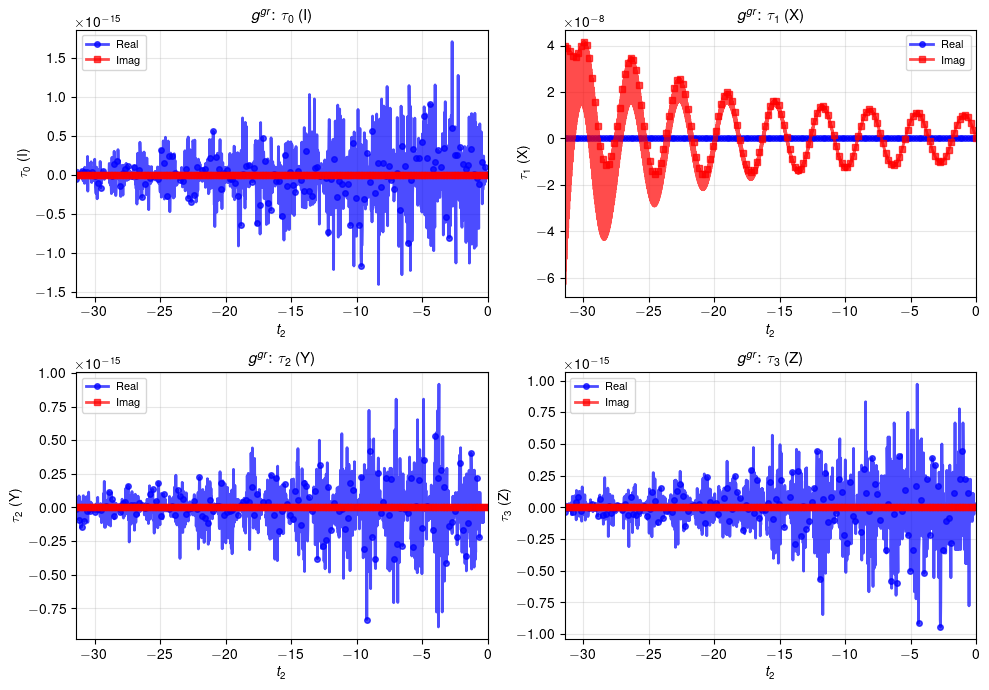


PLOTTING GK NORMALIZATION - Error Values

τ_0 component:
  Plotting range: [-5.6593e-22, 3.3640e-21]
  Mean error: 1.8269e-22
  Std deviation: 7.2110e-22
  Max error: 2.5765e-01

τ_1 component:
  Plotting range: [-4.6674e-04, 9.9422e-02]
  Mean error: 5.7987e-05
  Std deviation: 2.5661e-03
  Max error: 9.9422e-02

τ_2 component:
  Plotting range: [-1.0363e-33, 2.7384e-34]
  Mean error: -2.7901e-36
  Std deviation: 6.2345e-35
  Max error: 1.7764e-15

τ_3 component:
  Plotting range: [-9.0686e-35, 1.0255e-34]
  Mean error: -6.9377e-37
  Std deviation: 2.5734e-35
  Max error: 5.6066e-15



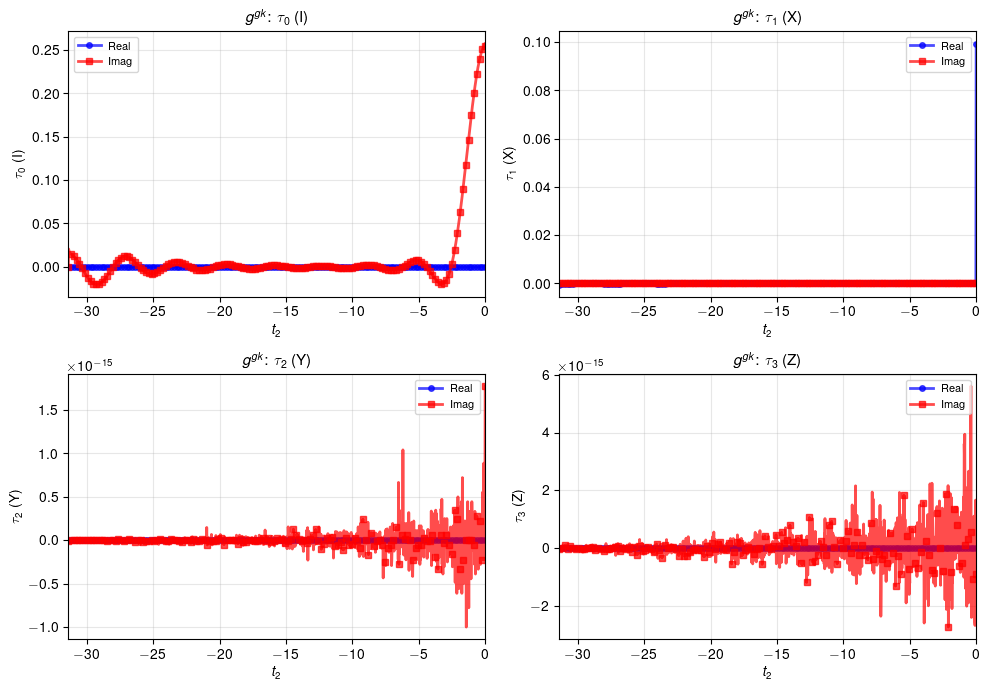


Normalization Check Results:
  gr errors per channel:
    τ₀: 1.71e-15
    τ₁: 6.28e-08
    τ₂: 9.16e-16
    τ₃: 9.71e-16
  gr max error: 6.28e-08 (in channel τ₁)

  gk errors per channel:
    τ₀: 2.58e-01
    τ₁: 9.94e-02
    τ₂: 1.78e-15
    τ₃: 5.61e-15
  gk max error: 2.58e-01 (in channel τ₀)


In [17]:
# Check gr and gk normalization relations
norm_results = da.check_normalizations(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']

print(f"\nNormalization Check Results:")
print(f"  gr errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gr_max_error'][i]:.2e}")
gr_max_idx = np.argmax(norm_results['gr_max_error'])
print(f"  gr max error: {norm_results['gr_max_error'][gr_max_idx]:.2e} (in channel {pauli_names[gr_max_idx]})")

print(f"\n  gk errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gk_max_error'][i]:.2e}")
gk_max_idx = np.argmax(norm_results['gk_max_error'])
print(f"  gk max error: {norm_results['gk_max_error'][gk_max_idx]:.2e} (in channel {pauli_names[gk_max_idx]})")

         Recommended: eta >= 5/T_max = 10/31.42
         Consider using larger T_max or increasing eta to avoid numerical issues.

FDT CHECK - Maximum Error Indices

τ_0 component:
  max_error = 1.5543e-15 at index 1421
  error_at_last_element = 6.0463e-35 + 0.0000e+00j

τ_1 component:
  max_error = 1.4988e-15 at index 1349
  error_at_last_element = 0.0000e+00 + -5.0337e-34j

τ_2 component:
  max_error = 1.0024e-01 at index 1494
  error_at_last_element = 0.0000e+00 + -4.9709e-02j

τ_3 component:
  max_error = 2.4035e-02 at index 0
  error_at_last_element = -2.9336e-25 + 0.0000e+00j



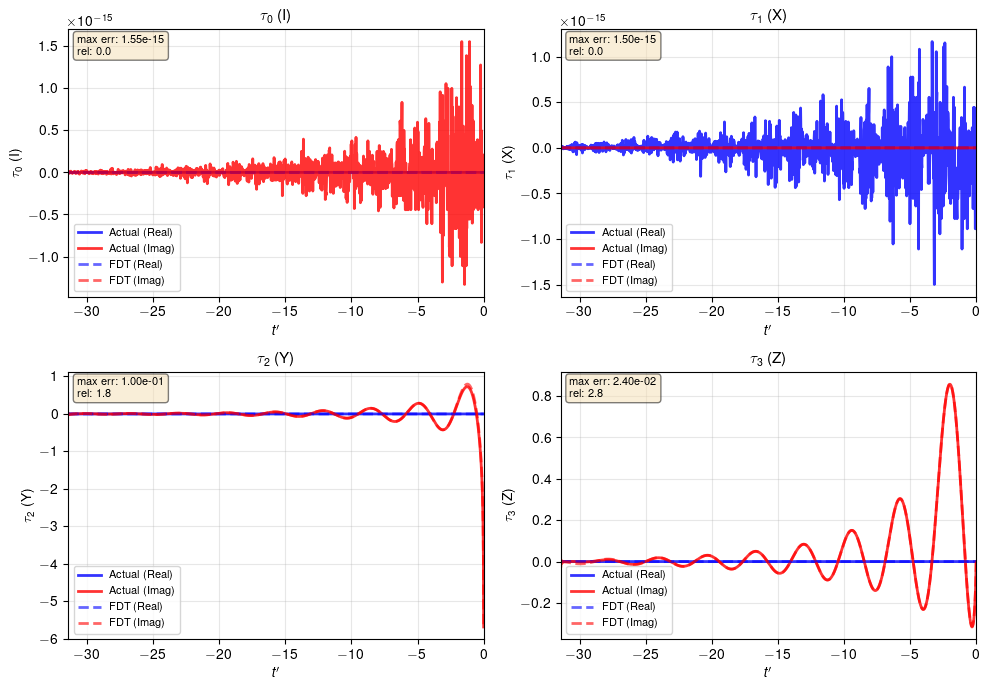


FDT Check Results:
  Errors per channel:
    τ₀: 1.55e-15
    τ₁: 1.50e-15
    τ₂: 1.00e-01
    τ₃: 2.40e-02
  Max error: 1.00e-01 (in channel τ₂)


In [19]:
# Check fluctuation-dissipation theorem
fdt_results = da.check_fdt(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']
print(f"\nFDT Check Results:")
print(f"  Errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {fdt_results['max_error'][i]:.2e}")
max_idx = np.argmax(fdt_results['max_error'])
print(f"  Max error: {fdt_results['max_error'][max_idx]:.2e} (in channel {pauli_names[max_idx]})")

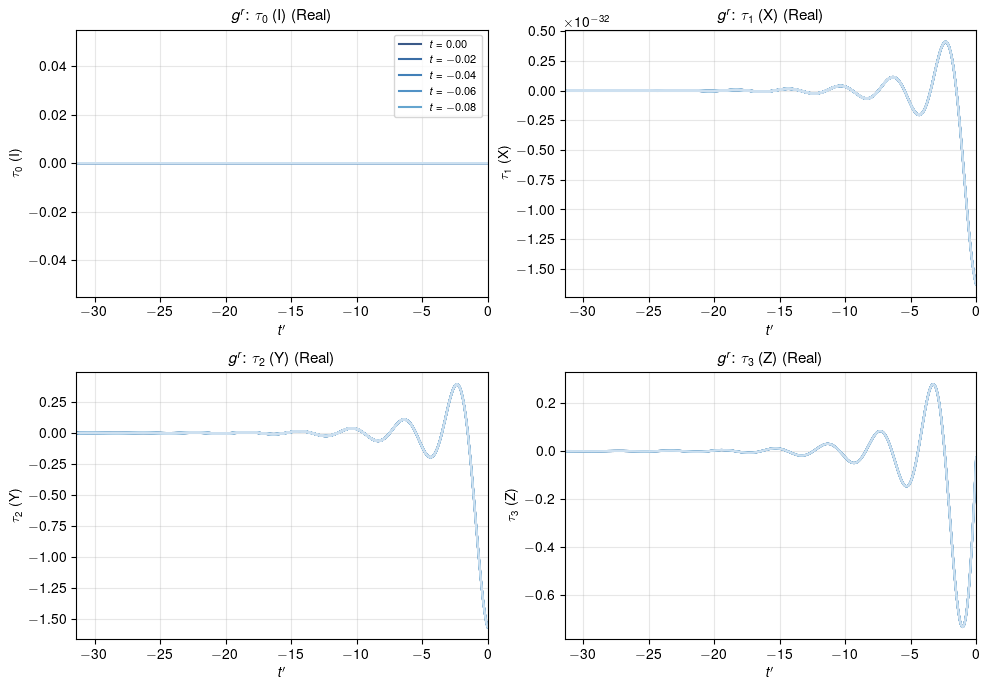

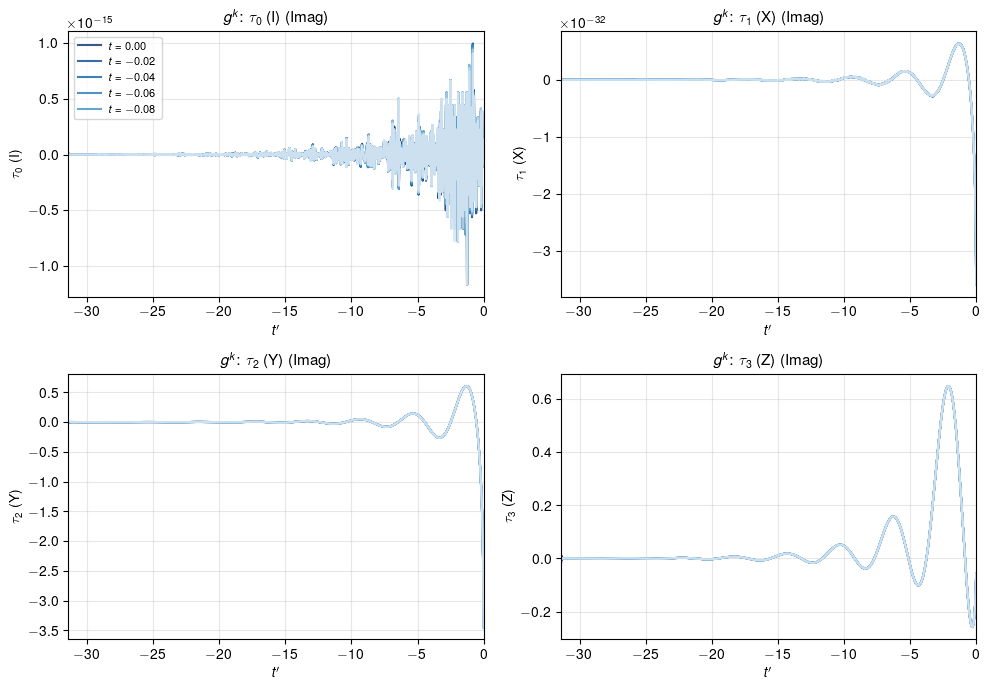


Time-Translation Invariance Results:
  gr max diffs per row: [0.0, np.float64(1.5764715906199769), np.float64(1.5764715906199769), np.float64(1.5764715906199769), np.float64(1.5764715906199769), np.float64(1.5764715906199769), np.float64(1.5764715906199769), np.float64(1.5764715906199769), np.float64(1.5764715906199769), np.float64(1.5764715906199769)]
  gr max diff: 1.58e+00 (in row 2 from last)

  gk max diffs per row: [0.0, np.float64(5.1541566624647075), np.float64(5.1541566624647075), np.float64(5.1541566624647075), np.float64(5.1541566624647075), np.float64(5.1541566624647075), np.float64(5.1541566624647075), np.float64(5.1541566624647075), np.float64(5.1541566624647075), np.float64(5.1541566624647075)]
  gk max diff: 5.15e+00 (in row 2 from last)

  Passed (threshold 1e-08): False


In [ ]:
# Check time-translation invariance (equilibrium test)
tti_results = da.check_time_translational_invariance(check_timestamp, check_job_index,
                                                      num_rows=10, threshold=1e-8, save_plot=False)

print(f"\nTime-Translation Invariance Results:")
print(f"  gr max diffs per row: {tti_results['max_diff_gr']}")
gr_max_idx = np.argmax(tti_results['max_diff_gr'])
print(f"  gr max diff: {tti_results['max_diff_gr'][gr_max_idx]:.2e} (in row {gr_max_idx + 1} from last)")

print(f"\n  gk max diffs per row: {tti_results['max_diff_gk']}")
gk_max_idx = np.argmax(tti_results['max_diff_gk'])
print(f"  gk max diff: {tti_results['max_diff_gk'][gk_max_idx]:.2e} (in row {gk_max_idx + 1} from last)")

print(f"\n  Passed (threshold {tti_results['threshold']:.0e}): {tti_results['passed']}")

# 2. Gap and Current Analysis

In [11]:
evolution_timestamp = '1781818157'
evolution_job_index = 4
equilibrium_timestamp = '1781703037'

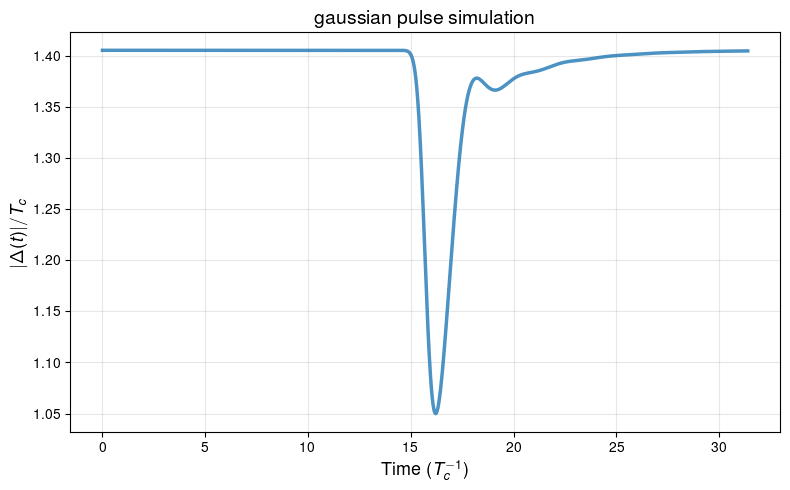

In [ ]:
# Plot gap evolution for this job
da.plot_gap(evolution_timestamp, evolution_job_index, save_plot=False)

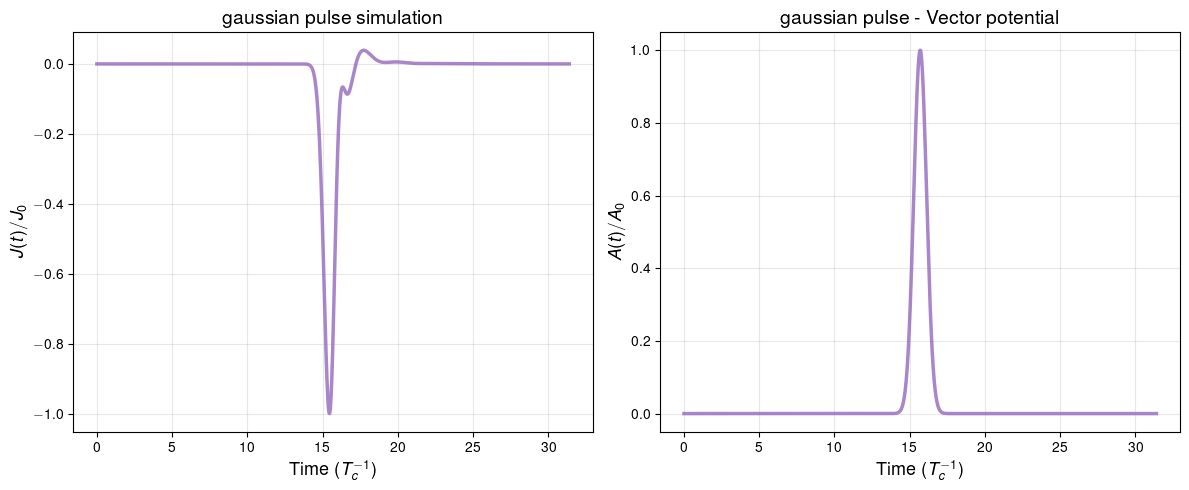

In [ ]:
# Plot current evolution for this job
da.plot_current(evolution_timestamp, evolution_job_index, save_plot=False)



Parameter validation (evolution vs equilibrium):
  eta: 0.2 ✓
  temperature: 0.5 ✓
  critical_temperature: 1 ✓
  Total time duration: 0.000000 ✓

Loading equilibrium sweep data...
Loaded equilibrium data: 24 points from A=0.000 to 0.600

Job 10: Plotting 1500 points
  Gap range: [0.133, 1.405]
  Current range: [-1.000, 0.551]
  A range: [2.095e-297, 1.071e+00]
  Time range: [0.000, 31.395]


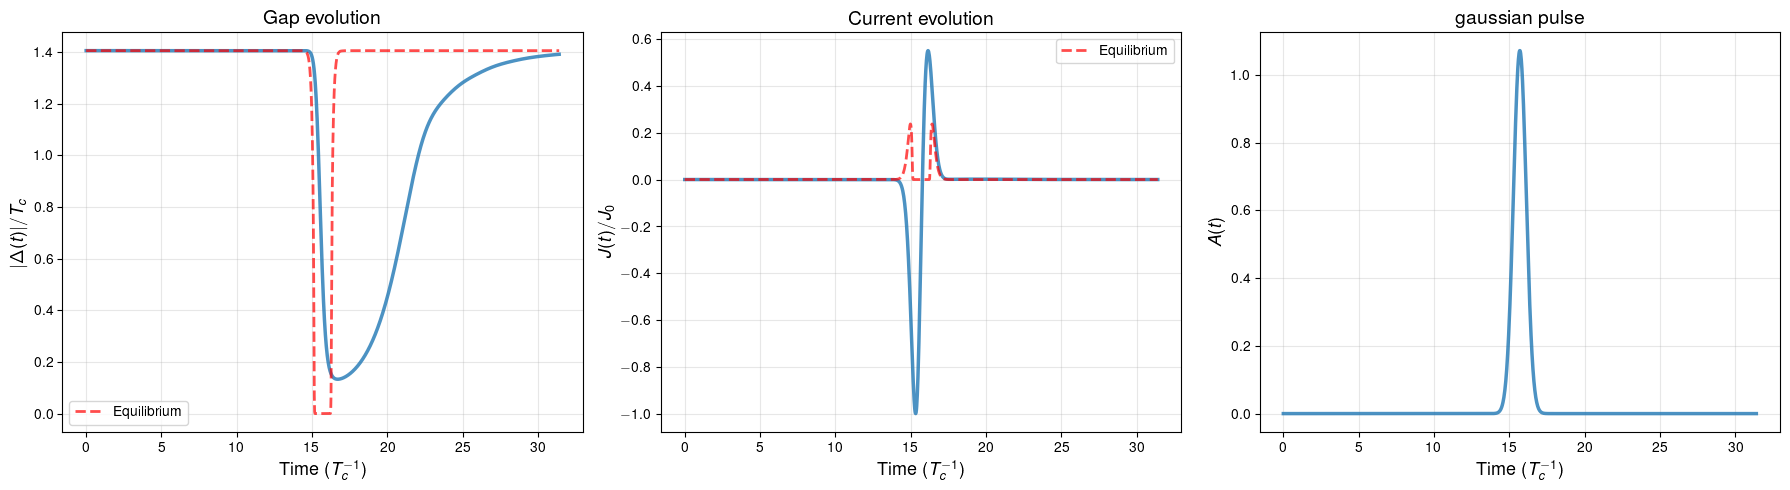

In [12]:
da.plot_gap_current_combined(
      timestamp=evolution_timestamp,           # Your time evolution run
      job_index=10,                      # Specific job to plot
      equilibrium_timestamp=equilibrium_timestamp,  # Your equilibrium sweep run
      n_average=100,                    # Average last 100 timesteps for equilibrium
      save_plot=False                    # Save to Figures/
  )


# 3. Parameter Sweep Analysis

Run this section to compare equilibrated gap/current across multiple timestamps.

In [22]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1781702763']  # Add more timestamps as needed: ['ts1', 'ts2', ...]
#'1781865083', 1781702763
# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'temperature'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: temperature
Timestamps to analyze: ['1781702763']
Averaging last 100 timesteps


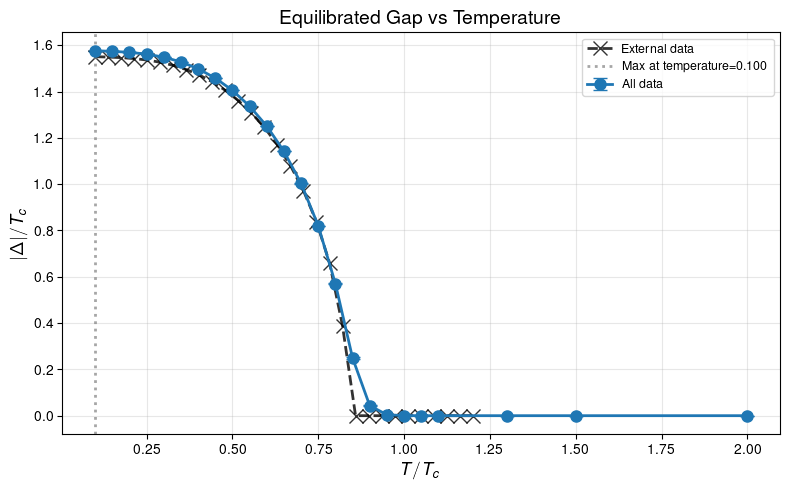


Gap Sweep Results:
  Parameter values: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.3  1.5  2.  ]
  Gap means: [ 1.57647158e+00+1.64803236e-32j  1.57390219e+00+1.62151833e-32j
  1.56962668e+00+1.60569770e-32j  1.56189614e+00+1.61793270e-32j
  1.54876516e+00+1.50343660e-32j  1.52831130e+00+1.52493121e-32j
  1.49875085e+00+1.54874206e-32j  1.45834710e+00+1.59150887e-32j
  1.40522343e+00+1.60558644e-32j  1.33710126e+00+1.26511107e-32j
  1.25090330e+00+1.44175066e-32j  1.14205094e+00+1.54473694e-32j
  1.00302913e+00+1.00099093e-32j  8.20270013e-01+9.87177745e-33j
  5.69686785e-01+7.25873420e-33j  2.49078121e-01+2.22192533e-33j
  4.32338939e-02+4.00031028e-34j  4.07038386e-03+4.03389704e-35j
  3.12507160e-04+7.86424547e-36j  2.21966039e-05+1.13698216e-36j
  1.58874167e-06+2.29588765e-37j  2.17586607e-09+2.06560611e-39j
  5.17849812e-11+1.85591940e-41j -1.66356313e-14-4.08763492e-42j]
  Gap errors: [7.54596089e-09 5.00271192e-0

In [23]:
# Plot equilibrated gap vs parameter
gap_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps, 
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, combine_timestamps = True,
    x_external = eq_T, y_external = eq_gap_mag_T
)


print(f"\nGap Sweep Results:")
print(f"  Parameter values: {gap_sweep_results['parameter_values']}")
print(f"  Gap means: {gap_sweep_results['gap_means']}")
print(f"  Gap errors: {gap_sweep_results['gap_errors']}")
print(f"\nMaximum Gap:")
print(f"  Max |Δ| = {gap_sweep_results['max_gap']:.4f}")
print(f"  At {sweep_parameter} = {gap_sweep_results['max_parameter']:.4f}")

In [ ]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1781703037']  # Add more timestamps as needed: ['ts1', 'ts2', ...]
#['1781703060', '1781703037', '1781702934']
# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'vector_potential'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: vector_potential
Timestamps to analyze: ['1781703037']
Averaging last 100 timesteps


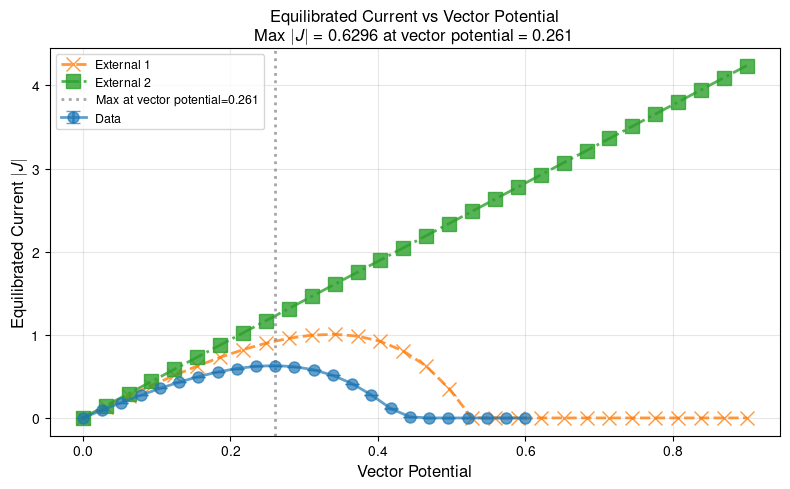

In [ ]:
# Plot equilibrated current vs parameter

current_sweep_results = da.plot_equilibrated_current_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = [eq_A,eq_A], y_external = [eq_current_A, eq_A * np.pi * 1.51812789 * np.tanh(1.51812789/2 / 0.3)]
)
#* added 1/2 factor for comparison since original current heory was wrong so to rescale. -- fixed in new version 

#print(np.pi * 1.51812789 * np.tanh(1.51812789/2 / 0.3)/2)
#print(np.max(eq_current_A))

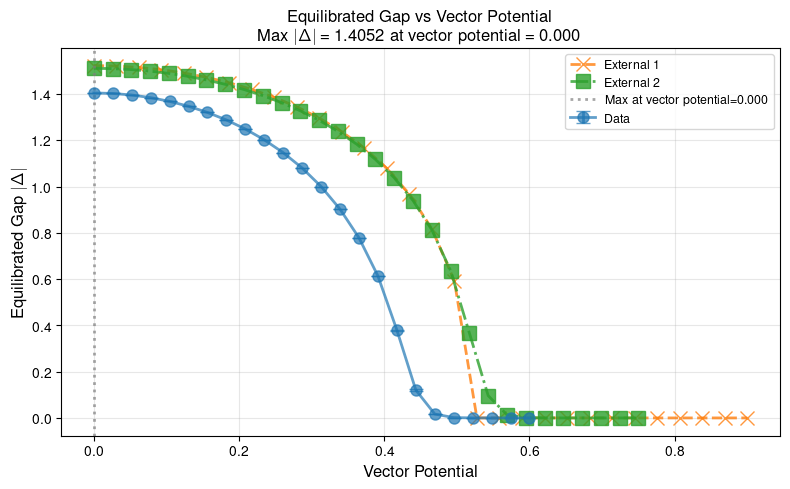

In [ ]:
x_jon = [0.        , 0.02586207 ,0.05172414 ,0.07758621 ,0.10344828, 0.12931034,
 0.15517241, 0.18103448, 0.20689655, 0.23275862, 0.25862069, 0.28448276,
 0.31034483, 0.3362069 , 0.36206897, 0.38793103, 0.4137931,  0.43965517,
 0.46551724, 0.49137931, 0.51724138, 0.54310345, 0.56896552, 0.59482759,
 0.62068966, 0.64655172, 0.67241379, 0.69827586, 0.72413793, 0.75]
y_jon = [1.51163408e+00, 1.51027885e+00, 1.50620005e+00, 1.49935768e+00,
 1.48968270e+00, 1.47707321e+00, 1.46138854e+00, 1.44244072e+00,
 1.41998222e+00, 1.39368837e+00, 1.36313217e+00, 1.32774717e+00,
 1.28677174e+00, 1.23916228e+00, 1.18345224e+00, 1.11750939e+00,
 1.03808374e+00, 9.39867391e-01, 8.13187470e-01, 6.36954560e-01,
 3.67131713e-01, 9.64004201e-02, 1.35302658e-02, 1.55015802e-03,
 1.64641301e-04, 1.68474568e-05, 1.68997743e-06, 1.67848029e-07,
 1.66168484e-08, 9.13836357e-09]

# Plot equilibrated current vs parameter
current_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = [eq_A,x_jon], y_external = [eq_gap_mag_A,y_jon]
)




# 4. Quasi-particle evolution dynamics 

In [ ]:
qp_timestamp = '1781709737'
qp_job_index = 0    


Energy-Time Plot (timestamp=1781709737, job_index=0):
  Green's function type: g^gr
  Pauli components: (2, 3)
  Total time slices available: 10
  Plotting every 150 slice(s): 1 lines
  Time range: [0.00, 0.19]
  Energy grid points: 1501



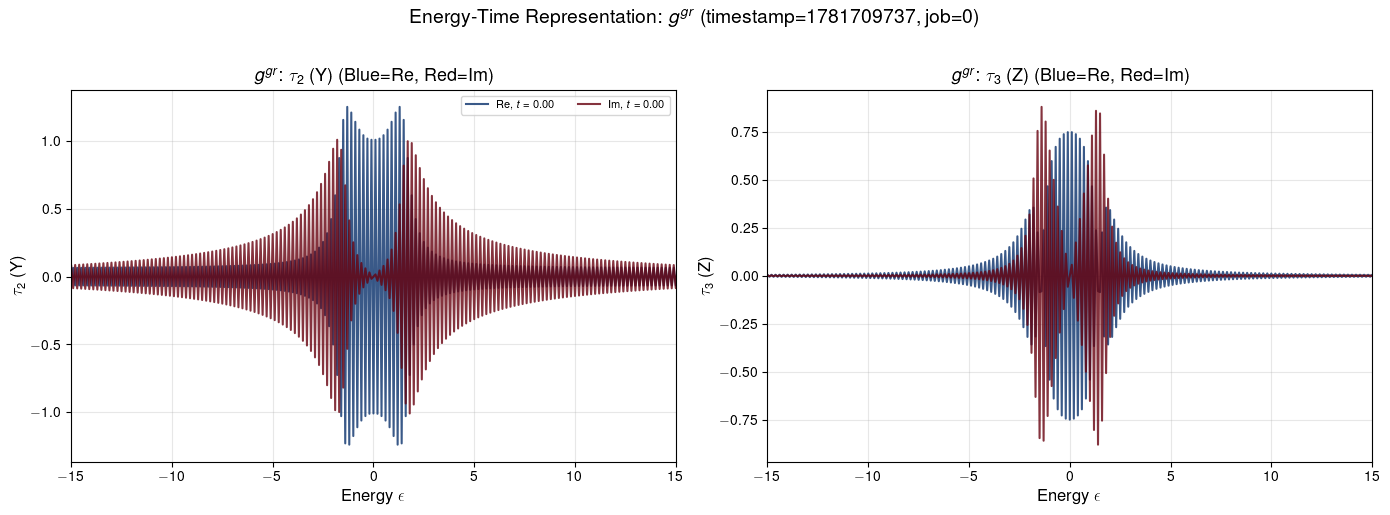

{'energy_grid': array([-74.95003331, -74.85009993, -74.75016656, ...,  74.75016656,
         74.85009993,  74.95003331], shape=(1501,)),
 'time_indices': array([0]),
 'time_values': array([0.]),
 'data': [{'energy_grid': array([-74.95003331, -74.85009993, -74.75016656, ...,  74.75016656,
           74.85009993,  74.95003331], shape=(1501,)),
   'g_energy': <nambu_keldysh_class.NambuKeldyshTensor at 0x7f302e102990>}]}

In [ ]:
da.plot_energy_time_representation(
    timestamp=qp_timestamp,  # Your timestamp
    job_index=qp_job_index,    # Your job index
    green_function_type='gr',
    pauli_components=(2, 3),  # tau_0 and tau_3
    plot_every= 150,             # Plot every 5th time slice
    save_plot=True
)


# 5. Linear response -- Conductivity 

Max |A(t)| = 9.985e-02

Time-domain boundary values:
  A(t_start) = 0.000e+00+0.000e+00j, A(t_end) = 0.000e+00+0.000e+00j
  j(t_start) = 0.000e+00+0.000e+00j, j(t_end) = 7.628e-07-1.399e-38j
  Max |A(t)| = 9.985e-02
  Max |j(t)| = 4.165e-01

Conductivity Extraction (timestamp=1781818237, job_index=1):
  Time step (dt): 0.020944
  Total duration (T_total): 31.395
  Number of time points: 1500
  Frequency resolution (Δω): 0.200000
  Nyquist frequency (ω_max): 150.000
  Equilibrium gap (Δ₀): 1.405223
  Max |A(ω)|: 2.287e+00
  Threshold: 1.000e-03
  Valid frequency range: [-20.400, 20.400]
  Number of valid frequency points: 204/1500



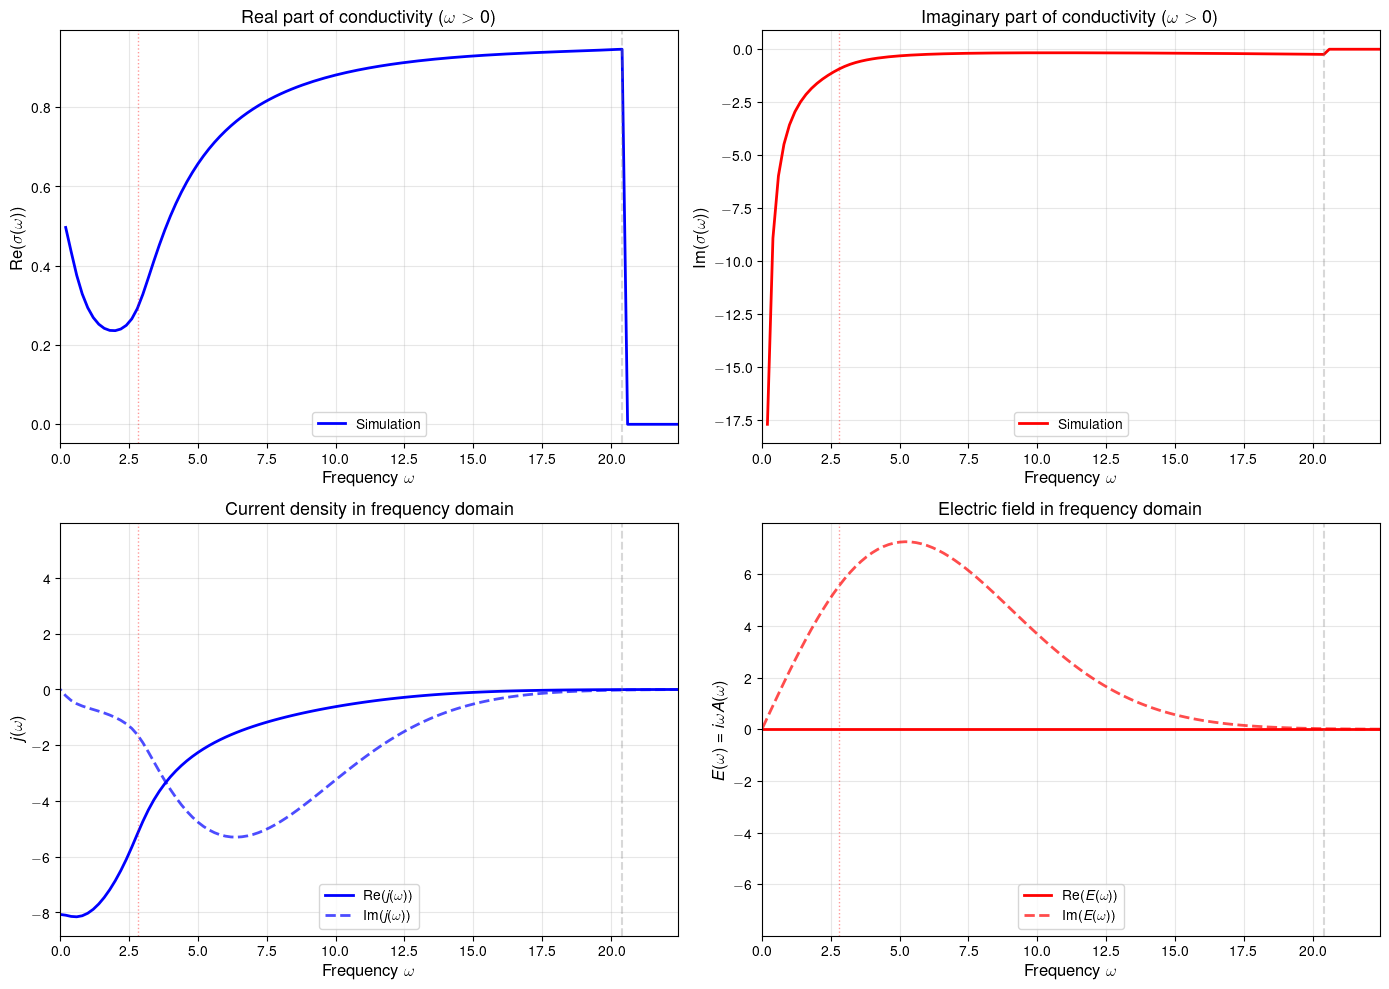

In [25]:
timestamp = '1781818237'  # Your timestamp
job_index = 1  # Your job index

result = da.extract_conductivity(
    timestamp=timestamp,
    job_index=job_index,
    threshold=1e-3,  # Filter out noise where |A(ω)| is small
    save_plot=False,  # Save the plot    
    save_dir=None
)
